#IMPORT LIBRARY



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#LOAD DATASET

In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/Dekhsa/Pelatihan-Member-DS-AMCC/refs/heads/main/Datasets/indonesia_corruption_data_updated.csv')
df = pd.DataFrame(df)
df

,Case_ID,Year,Province,Amount_Lost_IDR,Defendants,Verdict
0,1,2006,Sumatra,7.545693e+09,4.0,Guilty
1,2,2019,Sumatra,1.112058e+09,7.0,Not Guilty
2,3,2014,Kalimantan,1.322791e+10,4.0,Guilty
3,4,2010,Sulawesi,5.697989e+09,2.0,Not Guilty
4,5,2007,East Java,2.405513e+09,4.0,Guilty
...,...,...,...,...,...,...
998,999,2021,Kalimantan,0.000000e+00,0.0,Guilty
999,1000,2020,West Java,0.000000e+00,0.0,Ongoing
1000,522,2022,NaN,NaN,NaN,Not Guilty
1001,738,2008,NaN,NaN,NaN,Not Guilty


#MEMAHAMI DATASET

##1. Informasi data

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1003 entries, 0 to 1002
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Case_ID          1003 non-null   int64  
 1   Year             1003 non-null   int64  
 2   Province         945 non-null    object 
 3   Amount_Lost_IDR  940 non-null    float64
 4   Defendants       941 non-null    float64
 5   Verdict          998 non-null    object 
dtypes: float64(2), int64(2), object(2)
memory usage: 47.1+ KB


##2. Mejelaskan Data

In [ ]:
df.describe()

,Case_ID,Year,Amount_Lost_IDR,Defendants
count,1003.000000,1003.000000,9.400000e+02,941.000000
mean,500.998006,2012.000997,4.994469e+09,4.979809
std,288.584732,7.441656,3.457706e+09,2.626910
min,1.000000,2000.000000,0.000000e+00,0.000000
25%,251.500000,2005.000000,2.466735e+09,3.000000
50%,502.000000,2012.000000,4.954761e+09,5.000000
75%,749.500000,2018.500000,7.442294e+09,7.000000
max,1000.000000,2024.000000,5.968109e+10,9.000000


##3. Mencari Kategori Unik

In [ ]:
# kategori unik untuk province
unique_province = df['Province'].unique()
print(unique_province)

# kategori unik untuk Verdict
unique_Verdict = df['Verdict'].unique()
print(unique_Verdict)

['Sumatra' 'Kalimantan' 'Sulawesi' 'East Java' 'Central Java' 'Jakarta'
 'Bali' nan 'West Java' 'Sulawesy']
['Guilty' 'Not Guilty' 'Ongoing' nan 'Guiltee' 'Not Gilty']


#EXPLORATORY DATA ANALYSIS(EDA)

##1. Kualitas Data

In [ ]:
df_copy = df.copy()

###a. Zero Value

In [ ]:
# mencari zero value
rows_with_zero = df_copy[(df_copy == 0).any(axis=1)]
print(rows_with_zero)

     Case_ID  Year      Province  Amount_Lost_IDR  Defendants     Verdict
80        81  2015     East Java     0.000000e+00         9.0     Ongoing
87        88  2020    Kalimantan     0.000000e+00         3.0  Not Guilty
169      170  2012    Kalimantan     7.137657e+09         0.0      Guilty
250      251  2003     East Java     7.010453e+09         0.0     Ongoing
295      296  2000    Kalimantan     0.000000e+00         2.0      Guilty
304      305  2019          Bali     4.902752e+09         0.0      Guilty
432      433  2021  Central Java     0.000000e+00         1.0  Not Guilty
768      769  2014       Sumatra     1.556930e+09         0.0      Guilty
811      812  2001           NaN              NaN         0.0      Guilty
886      887  2007       Sumatra     0.000000e+00         8.0      Guilty
995      996  2024          Bali     0.000000e+00         0.0      Guilty
996      997  2000       Sumatra     0.000000e+00         0.0  Not Guilty
997      998  2020    Kalimantan     0

In [ ]:
# mengubah data zero ke NaN
df_copy['Amount_Lost_IDR'] = df_copy['Amount_Lost_IDR'].replace(0, np.nan)
df_copy['Defendants'] = df_copy['Defendants'].replace(0, np.nan)

In [ ]:
# cek ulang zero value

df_copy[(df_copy == 0).any(axis=1)]

,Case_ID,Year,Province,Amount_Lost_IDR,Defendants,Verdict


###b. Missing Value

In [ ]:
mv = df_copy[df_copy.isnull().any(axis=1)]
mv

,Case_ID,Year,Province,Amount_Lost_IDR,Defendants,Verdict
21,22,2011,NaN,1.648602e+09,4.0,Guilty
38,39,2019,NaN,1.900659e+09,5.0,Not Guilty
59,60,2007,NaN,NaN,NaN,Guilty
76,77,2001,NaN,NaN,NaN,Not Guilty
80,81,2015,East Java,NaN,9.0,Ongoing
...,...,...,...,...,...,...
998,999,2021,Kalimantan,NaN,NaN,Guilty
999,1000,2020,West Java,NaN,NaN,Ongoing
1000,522,2022,NaN,NaN,NaN,Not Guilty
1001,738,2008,NaN,NaN,NaN,Not Guilty


In [ ]:
# mengisi fitur numerik

# median
df_copy['Defendants'].fillna(df_copy['Defendants'].median(), inplace = True)
df_copy['Amount_Lost_IDR'].fillna(df_copy['Amount_Lost_IDR'].median(), inplace = True)

<ipython-input-11-d01edaeff578>:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_copy['Defendants'].fillna(df_copy['Defendants'].median(), inplace = True)
<ipython-input-11-d01edaeff578>:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(val

In [ ]:
# Imputasi fitur kategorikal (impute)

# Import Library
from sklearn.impute import SimpleImputer
df_filled = SimpleImputer(strategy='most_frequent').fit_transform(df_copy)
df_filled = pd.DataFrame(df_filled, columns=df_copy.columns)
df_filled

,Case_ID,Year,Province,Amount_Lost_IDR,Defendants,Verdict
0,1,2006,Sumatra,7545693324.0,4.0,Guilty
1,2,2019,Sumatra,1112057931.0,7.0,Not Guilty
2,3,2014,Kalimantan,13227906516.0,4.0,Guilty
3,4,2010,Sulawesi,5697988826.0,2.0,Not Guilty
4,5,2007,East Java,2405513000.0,4.0,Guilty
...,...,...,...,...,...,...
998,999,2021,Kalimantan,5004698351.5,5.0,Guilty
999,1000,2020,West Java,5004698351.5,5.0,Ongoing
1000,522,2022,Central Java,5004698351.5,5.0,Not Guilty
1001,738,2008,Central Java,5004698351.5,5.0,Not Guilty


In [ ]:
#recheck data hilang
df_filled[df_filled.isnull().any(axis=1)]

,Case_ID,Year,Province,Amount_Lost_IDR,Defendants,Verdict


###c. Data Inkonsisten/typo

In [ ]:
# cek tipe data
for col in df_filled.columns:
  print(f"Inkonsistensi di kolom '{col}' : ")
  print(df_filled[col].apply(type).value_counts())
  print("-" * 20)

  # cek inkonsistensi di kolom kategorikal
for col in ['Province', 'Verdict']:
  print(f"Value unik dan jumlahnya di kolom '{col}' : ")
  print(df_filled[col].value_counts(dropna=False))
  print("-" * 20)

Inkonsistensi di kolom 'Case_ID' : 
Case_ID
<class 'int'>    1003
Name: count, dtype: int64
--------------------
Inkonsistensi di kolom 'Year' : 
Year
<class 'int'>    1003
Name: count, dtype: int64
--------------------
Inkonsistensi di kolom 'Province' : 
Province
<class 'str'>    1003
Name: count, dtype: int64
--------------------
Inkonsistensi di kolom 'Amount_Lost_IDR' : 
Amount_Lost_IDR
<class 'float'>    1003
Name: count, dtype: int64
--------------------
Inkonsistensi di kolom 'Defendants' : 
Defendants
<class 'float'>    1003
Name: count, dtype: int64
--------------------
Inkonsistensi di kolom 'Verdict' : 
Verdict
<class 'str'>    1003
Name: count, dtype: int64
--------------------
Value unik dan jumlahnya di kolom 'Province' : 
Province
Central Java    188
Sumatra         123
Kalimantan      121
Bali            120
Jakarta         119
West Java       117
Sulawesi        113
East Java       101
Sulawesy          1
Name: count, dtype: int64
--------------------
Value unik dan j

In [ ]:
# Membetulkan Inkonsistensi
df_filled['Province'] = df_filled['Province'].replace('Sulawesy', 'Sulawesi')
df_filled['Verdict'] = df_filled['Verdict'].replace('Guiltee', 'Guilty')
df_filled['Verdict'] = df_filled['Verdict'].replace('Not Gilty', 'Not Guilty')

In [ ]:
# Recheck
print("Province = ", df_filled['Province'].unique())
print("Verdict = ", df_filled['Verdict'].unique())

Province =  ['Sumatra' 'Kalimantan' 'Sulawesi' 'East Java' 'Central Java' 'Jakarta'
 'Bali' 'West Java']
Verdict =  ['Guilty' 'Not Guilty' 'Ongoing']


###d. Data Duplikat

In [ ]:
# cek data duplikat
duplicated = df_filled.loc[df_filled.duplicated()]
duplicated

,Case_ID,Year,Province,Amount_Lost_IDR,Defendants,Verdict
1000,522,2022,Central Java,5004698351.5,5.0,Not Guilty
1001,738,2008,Central Java,5004698351.5,5.0,Not Guilty
1002,741,2016,Central Java,5004698351.5,5.0,Guilty


In [ ]:
# menghapus data duplikat
df_clean = df_filled.drop_duplicates()
df_clean

,Case_ID,Year,Province,Amount_Lost_IDR,Defendants,Verdict
0,1,2006,Sumatra,7545693324.0,4.0,Guilty
1,2,2019,Sumatra,1112057931.0,7.0,Not Guilty
2,3,2014,Kalimantan,13227906516.0,4.0,Guilty
3,4,2010,Sulawesi,5697988826.0,2.0,Not Guilty
4,5,2007,East Java,2405513000.0,4.0,Guilty
...,...,...,...,...,...,...
995,996,2024,Bali,5004698351.5,5.0,Guilty
996,997,2000,Sumatra,5004698351.5,5.0,Not Guilty
997,998,2020,Kalimantan,5004698351.5,5.0,Ongoing
998,999,2021,Kalimantan,5004698351.5,5.0,Guilty


In [ ]:
# recheck data duplikat
df_clean.loc[df_clean.duplicated()]


,Case_ID,Year,Province,Amount_Lost_IDR,Defendants,Verdict


##2. Menghandle Outlier

<Axes: xlabel='Amount_Lost_IDR'>

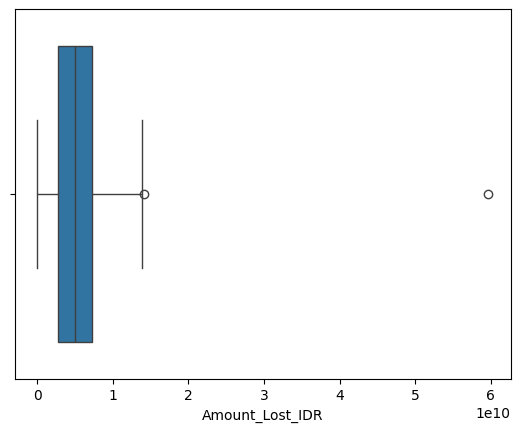

In [ ]:
# Visualisasi Outlier
sns.boxplot(x=df_clean['Amount_Lost_IDR'])

In [ ]:
# Mencari Q1 dan Q3 untuk IQR
Q1 = df_clean.Amount_Lost_IDR.quantile(0.25)
Q3 = df_clean.Amount_Lost_IDR.quantile(0.75)
IQR = Q3 - Q1

In [ ]:
# Mencari batas atas dan bawah
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(lower_bound, upper_bound)

-4060897036.0 14057714620.0


In [ ]:
# Outlier
df_outlier = df_clean[(df_clean.Amount_Lost_IDR < lower_bound) | (df_clean.Amount_Lost_IDR > upper_bound)]
df_outlier

,Case_ID,Year,Province,Amount_Lost_IDR,Defendants,Verdict
889,890,2024,Central Java,14150034060.0,6.0,Ongoing
961,962,2021,Sulawesi,59681087829.0,9.0,Not Guilty


In [ ]:
# Data Bersih dari Outlier
df_clean = df_clean[(df_clean.Amount_Lost_IDR > lower_bound) & (df_clean.Amount_Lost_IDR < upper_bound)]

<Axes: xlabel='Amount_Lost_IDR'>

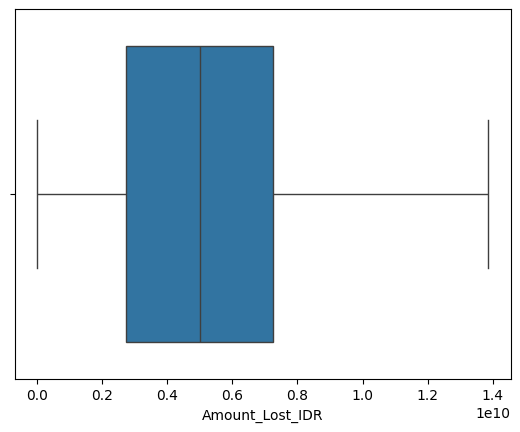

In [ ]:
# Recheck outlier
sns.boxplot(x=df_clean['Amount_Lost_IDR'])

##3. Feature Engineering


###a. One Hot Encoding

In [ ]:
from sklearn.preprocessing import OneHotEncoder

# Encode Verdict
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False).set_output(transform='pandas')
df_ohe = ohe.fit_transform(df_clean[['Verdict']])
df_ohe


,Verdict_Guilty,Verdict_Not Guilty,Verdict_Ongoing
0,1.0,0.0,0.0
1,0.0,1.0,0.0
2,1.0,0.0,0.0
3,0.0,1.0,0.0
4,1.0,0.0,0.0
...,...,...,...
995,1.0,0.0,0.0
996,0.0,1.0,0.0
997,0.0,0.0,1.0
998,1.0,0.0,0.0


In [ ]:
# Df input OHE ke Dataframe Utama

df_encode = pd.concat([df_clean,df_ohe], axis = 1).drop(columns=['Verdict'], axis = 1)
df_encode

,Case_ID,Year,Province,Amount_Lost_IDR,Defendants,Verdict_Guilty,Verdict_Not Guilty,Verdict_Ongoing
0,1,2006,Sumatra,7545693324.0,4.0,1.0,0.0,0.0
1,2,2019,Sumatra,1112057931.0,7.0,0.0,1.0,0.0
2,3,2014,Kalimantan,13227906516.0,4.0,1.0,0.0,0.0
3,4,2010,Sulawesi,5697988826.0,2.0,0.0,1.0,0.0
4,5,2007,East Java,2405513000.0,4.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...
995,996,2024,Bali,5004698351.5,5.0,1.0,0.0,0.0
996,997,2000,Sumatra,5004698351.5,5.0,0.0,1.0,0.0
997,998,2020,Kalimantan,5004698351.5,5.0,0.0,0.0,1.0
998,999,2021,Kalimantan,5004698351.5,5.0,1.0,0.0,0.0


###b. Menambah Fitur Baru

In [ ]:
df_encode['Amount_Lost_per_Defendants'] = df_encode['Amount_Lost_IDR'] / df_encode['Defendants']
df_encode

,Case_ID,Year,Province,Amount_Lost_IDR,Defendants,Verdict_Guilty,Verdict_Not Guilty,Verdict_Ongoing,Amount_Lost_per_Defendants
0,1,2006,Sumatra,7545693324.0,4.0,1.0,0.0,0.0,1886423331.0
1,2,2019,Sumatra,1112057931.0,7.0,0.0,1.0,0.0,158865418.714286
2,3,2014,Kalimantan,13227906516.0,4.0,1.0,0.0,0.0,3306976629.0
3,4,2010,Sulawesi,5697988826.0,2.0,0.0,1.0,0.0,2848994413.0
4,5,2007,East Java,2405513000.0,4.0,1.0,0.0,0.0,601378250.0
...,...,...,...,...,...,...,...,...,...
995,996,2024,Bali,5004698351.5,5.0,1.0,0.0,0.0,1000939670.3
996,997,2000,Sumatra,5004698351.5,5.0,0.0,1.0,0.0,1000939670.3
997,998,2020,Kalimantan,5004698351.5,5.0,0.0,0.0,1.0,1000939670.3
998,999,2021,Kalimantan,5004698351.5,5.0,1.0,0.0,0.0,1000939670.3


###c. Normalisasi Data

In [ ]:
# Menghapus data kategorikal
df_num = df_encode.drop(columns=['Province', 'Year', 'Case_ID'])
df_num

,Amount_Lost_IDR,Defendants,Verdict_Guilty,Verdict_Not Guilty,Verdict_Ongoing,Amount_Lost_per_Defendants
0,7545693324.0,4.0,1.0,0.0,0.0,1886423331.0
1,1112057931.0,7.0,0.0,1.0,0.0,158865418.714286
2,13227906516.0,4.0,1.0,0.0,0.0,3306976629.0
3,5697988826.0,2.0,0.0,1.0,0.0,2848994413.0
4,2405513000.0,4.0,1.0,0.0,0.0,601378250.0
...,...,...,...,...,...,...
995,5004698351.5,5.0,1.0,0.0,0.0,1000939670.3
996,5004698351.5,5.0,0.0,1.0,0.0,1000939670.3
997,5004698351.5,5.0,0.0,0.0,1.0,1000939670.3
998,5004698351.5,5.0,1.0,0.0,0.0,1000939670.3


In [ ]:
df_num.info()

<class 'pandas.core.frame.DataFrame'>
Index: 998 entries, 0 to 999
Data columns (total 6 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Amount_Lost_IDR             998 non-null    object 
 1   Defendants                  998 non-null    object 
 2   Verdict_Guilty              998 non-null    float64
 3   Verdict_Not Guilty          998 non-null    float64
 4   Verdict_Ongoing             998 non-null    float64
 5   Amount_Lost_per_Defendants  998 non-null    object 
dtypes: float64(3), object(3)
memory usage: 86.9+ KB


In [ ]:
# Scaling menggunakan MinMaxScaler
from sklearn.preprocessing import MinMaxScaler


scaleMinMax = MinMaxScaler(feature_range=(0,1))
df_scaled = scaleMinMax.fit_transform(df_num)
df_scaled = pd.DataFrame(df_scaled, columns=df_num.columns)
df_scaled


,Amount_Lost_IDR,Defendants,Verdict_Guilty,Verdict_Not Guilty,Verdict_Ongoing,Amount_Lost_per_Defendants
0,0.544043,0.375,1.0,0.0,0.0,0.193302
1,0.080001,0.750,0.0,1.0,0.0,0.016240
2,0.953887,0.375,1.0,0.0,0.0,0.338898
3,0.410773,0.125,0.0,1.0,0.0,0.291958
4,0.173294,0.375,1.0,0.0,0.0,0.061594
...,...,...,...,...,...,...
993,0.360767,0.500,1.0,0.0,0.0,0.102546
994,0.360767,0.500,0.0,1.0,0.0,0.102546
995,0.360767,0.500,0.0,0.0,1.0,0.102546
996,0.360767,0.500,1.0,0.0,0.0,0.102546


In [ ]:
df_scaled.describe()

,Amount_Lost_IDR,Defendants,Verdict_Guilty,Verdict_Not Guilty,Verdict_Ongoing,Amount_Lost_per_Defendants
count,998.000000,998.000000,998.000000,998.000000,998.000000,998.000000
mean,0.359077,0.503257,0.310621,0.336673,0.352705,0.156087
std,0.203064,0.312201,0.462980,0.472809,0.478052,0.178034
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.196795,0.250000,0.000000,0.000000,0.000000,0.051164
50%,0.360767,0.500000,0.000000,0.000000,0.000000,0.102546
75%,0.522285,0.750000,1.000000,1.000000,1.000000,0.174997
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


##Visualisasi

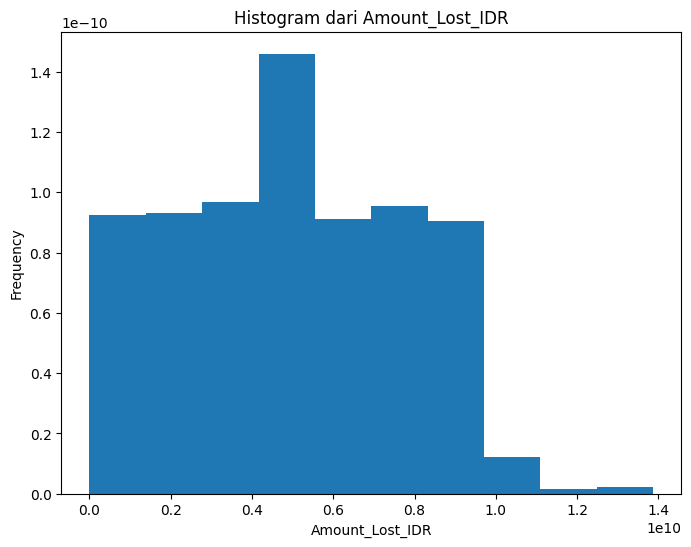

In [ ]:
plt.figure(figsize=(8,6))
plt.hist(df_encode['Amount_Lost_IDR'], density=True)
plt.xlabel('Amount_Lost_IDR')
plt.ylabel('Frequency')
plt.title('Histogram dari Amount_Lost_IDR')
plt.show()

Text(0.5, 1.0, 'Line Plot dari Amount_Lost_IDR terhadap Year')

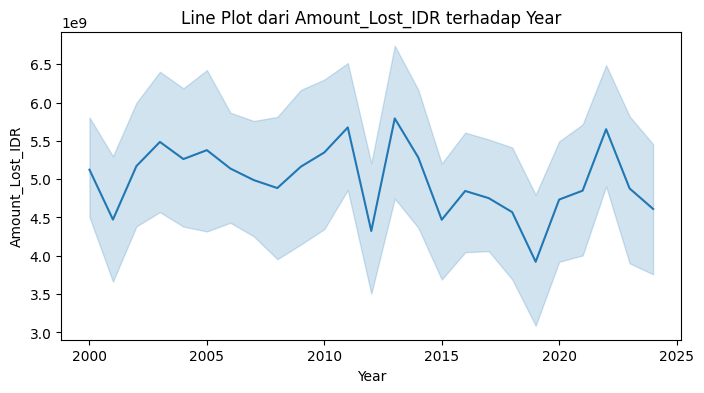

In [ ]:
# Contoh Line Plot
plt.figure(figsize=(8,4))
sns.lineplot(x=df_encode['Year'], y=df_encode['Amount_Lost_IDR'])
plt.xlabel('Year')
plt.ylabel('Amount_Lost_IDR')
plt.title('Line Plot dari Amount_Lost_IDR terhadap Year')